## Problem Statement - To apply the artificial immune pattern recognition to perform a task of structure damage Classification.

In [26]:
import numpy as np
import pandas as pd
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [27]:
# Step 1: Load Data
# -----------------------------------
def load_data():
    print("Loading dataset...")
    
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
    df = pd.read_csv(url)
    
    # Target
    y = df['Machine failure'].values
    
    # Features
    X = df.drop(columns=['UDI', 'Product ID', 'Type', 'Machine failure',
                         'TWF', 'HDF', 'PWF', 'OSF', 'RNF']).values
    
    return X, y

In [28]:
# Step 2: Initialize Antibodies
# -----------------------------------
def initialize_antibodies(X, y, num):
    antibodies = []
    labels = []
    
    for _ in range(num):
        idx = random.randint(0, len(X) - 1)
        antibodies.append(X[idx])
        labels.append(y[idx])
    
    return np.array(antibodies), np.array(labels)

In [29]:
# Step 3: Training (Clonal Selection)
# -----------------------------------
def train_aipr(X, y, antibodies, labels, epochs=3):
    
    for ep in range(epochs):
        print("Epoch", ep + 1)
        
        for i in range(len(X)):
            antigen = X[i]
            true_label = y[i]
            
            # Find best antibody of same class
            best_idx = -1
            best_dist = float('inf')
            
            for j in range(len(antibodies)):
                if labels[j] == true_label:
                    dist = np.linalg.norm(antibodies[j] - antigen)
                    
                    if dist < best_dist:
                        best_dist = dist
                        best_idx = j
            
            # Cloning + Mutation
            if best_idx != -1:
                best_ab = antibodies[best_idx].copy()
                
                for _ in range(3):  # number of clones
                    clone = best_ab.copy()
                    
                    # Mutation (small change)
                    noise = np.random.normal(0, 0.1, size=len(clone))
                    clone = clone + noise
                    
                    # Check improvement
                    dist_clone = np.linalg.norm(clone - antigen)
                    
                    if dist_clone < best_dist:
                        antibodies[best_idx] = clone
                        best_dist = dist_clone
    
    return antibodies, labels

In [30]:
# Step 4: Prediction
# -----------------------------------
def predict(X, antibodies, labels):
    predictions = []
    
    for antigen in X:
        best_idx = 0
        best_dist = float('inf')
        
        for j in range(len(antibodies)):
            dist = np.linalg.norm(antibodies[j] - antigen)
            
            if dist < best_dist:
                best_dist = dist
                best_idx = j
        
        predictions.append(labels[best_idx])
    
    return np.array(predictions)

In [31]:
# Main Execution
# -----------------------------------
X, y = load_data()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize antibodies
antibodies, labels = initialize_antibodies(X_train, y_train, num=100)

# Train AIPR model
antibodies, labels = train_aipr(X_train, y_train, antibodies, labels)

# Prediction
y_pred = predict(X_test, antibodies, labels)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("\nFinal Accuracy:", accuracy * 100, "%")

Loading dataset...
Epoch 1
Epoch 2
Epoch 3

Final Accuracy: 96.39999999999999 %



Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1939
           1       0.24      0.08      0.12        61

    accuracy                           0.96      2000
   macro avg       0.60      0.54      0.55      2000
weighted avg       0.95      0.96      0.96      2000



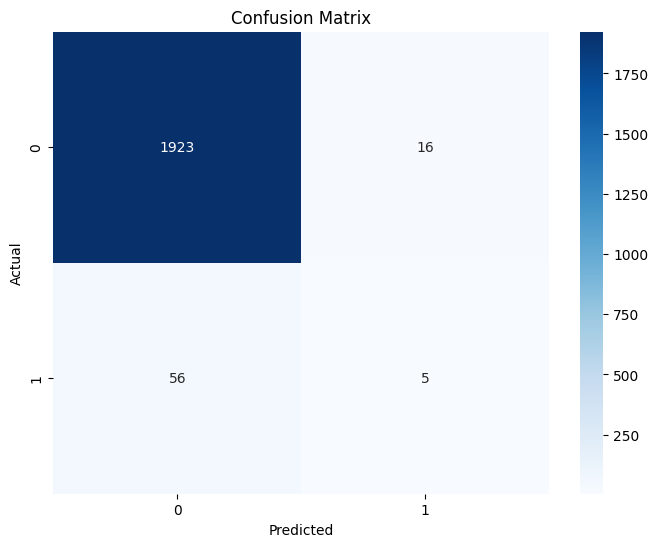

In [32]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()